# Simulación del Atractor de Lorenz

- Algoritmo del Método de Euler
  
El **método de Euler** es un método numérico para aproximar soluciones de ecuaciones diferenciales ordinarias de primer orden con una condición inicial dada. Se basa en usar la pendiente de la tangente (calculada con la derivada) para avanzar paso a paso en el intervalo de integración.

## Fórmula general

Para una ecuación diferencial de la forma:
\begin{align*}
\frac{dy}{dt} = f(t, y), \quad a \leq t \leq b, \quad y(a) = \alpha
\end{align*}

El método de Euler se define como:
$$
w_{i+1} = w_i + h f(t_i, w_i)
$$

donde:
- \( h \) es el tamaño del paso: \( h = \frac{b-a}{N} \)
- \( t_i = a + ih \)
- \( w_i \) es la aproximación de \( y(t_i) \)

# Características clave:
- Se generan aproximaciones en puntos discretos (puntos de malla) del intervalo [a, b]
- Los puntos de malla están igualmente espaciados: 
\( t_i = a + ih \) con \( i = 0,1,2,\ldots,N \)
- El tamaño de paso es (h) = (b - a)/N
- La solución entre puntos se obtiene por interpolación



In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Definición del sistema de Lorenz
def lorenz_system(x, y, z, sigma, rho, beta):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return dx, dy, dz

In [6]:
# Método de Euler
def euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max):
    xs, ys, zs = [x0], [y0], [z0]
    x, y, z = x0, y0, z0
    steps = int(t_max / dt)
    for _ in range(steps):
        dx, dy, dz = lorenz_system(x, y, z, sigma, rho, beta)
        x += dx * dt
        y += dy * dt
        z += dz * dt
        xs.append(x)
        ys.append(y)
        zs.append(z)
    return xs, ys, zs

In [7]:
# Parámetros y condiciones iniciales
dt = 0.01
t_max = 70

cases = [
    {"rho": 28, "sigma": 10, "beta": 8/3, "init": (1, 1, 1)},
    {"rho": 28, "sigma": 10, "beta": 8/3, "init": (1.002025, 0.2, 0.4)},
    {"rho": 18, "sigma": 9,  "beta": 10/3, "init": (2, 0.009, 0.7)},
]

In [8]:
# Función para graficar resultados
def plot_lorenz(xs, ys, zs, title):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot(xs, ys, zs)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.tight_layout()
    plt.show()


Simulando caso 1 con parámetros: {'rho': 28, 'sigma': 10, 'beta': 2.6666666666666665, 'init': (1, 1, 1)}


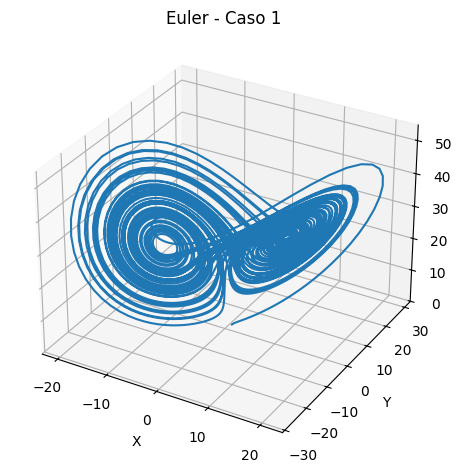

t= 70.00 s, X final: 0.4592, Y final: 6.7261, Z final: 28.6360

Simulando caso 2 con parámetros: {'rho': 28, 'sigma': 10, 'beta': 2.6666666666666665, 'init': (1.002025, 0.2, 0.4)}


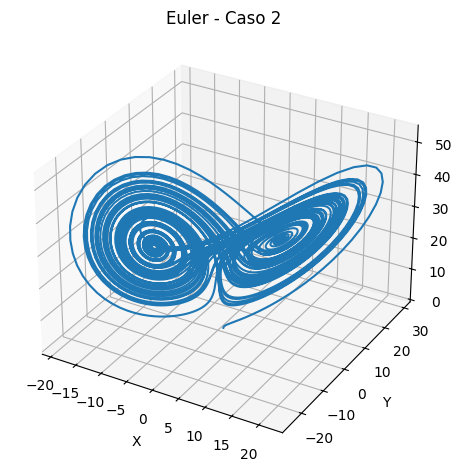

t= 70.00 s, X final: -7.4380, Y final: -7.8141, Z final: 25.1976

Simulando caso 3 con parámetros: {'rho': 18, 'sigma': 9, 'beta': 3.3333333333333335, 'init': (2, 0.009, 0.7)}


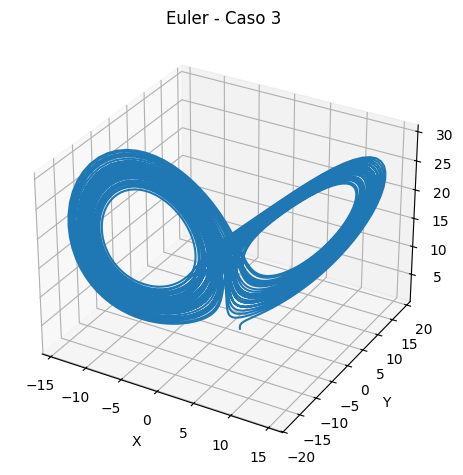

t= 70.00 s, X final: -13.6575, Y final: -11.9046, Z final: 26.8849


In [9]:
# Simulación y graficación
for i, case in enumerate(cases):
    print(f"\nSimulando caso {i+1} con parámetros: {case}")
    rho, sigma, beta = case["rho"], case["sigma"], case["beta"]
    x0, y0, z0 = case["init"]

    # Euler
    xs_e, ys_e, zs_e = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
    plot_lorenz(xs_e, ys_e, zs_e, f"Euler - Caso {i+1}")
    print(f"t= {t_max :.2f} s, X final: {xs_e[-1]:.4f}, Y final: {ys_e[-1]:.4f}, Z final: {zs_e[-1]:.4f}")


In [11]:
def plot_lorenz_case(x0, y0, z0, sigma, rho, beta, dt, t_max):
    # Calcular las soluciones usando el método de Euler
    xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
    steps = int(t_max / dt)
    time = np.linspace(0, t_max, steps + 1)

    # Graficar variables por separado
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axs[0].plot(time, xs, color='blue')
    axs[0].set_ylabel('x(t)')
    axs[0].set_title('Evolución de x en el tiempo')

    axs[1].plot(time, ys, color='green')
    axs[1].set_ylabel('y(t)')
    axs[1].set_title('Evolución de y en el tiempo')

    axs[2].plot(time, zs, color='red')
    axs[2].set_ylabel('z(t)')
    axs[2].set_xlabel('Tiempo')
    axs[2].set_title('Evolución de z en el tiempo')

    plt.tight_layout()
    plt.show()


Simulando caso 1 con parámetros: {'rho': 28, 'sigma': 10, 'beta': 2.6666666666666665, 'init': (1, 1, 1)}


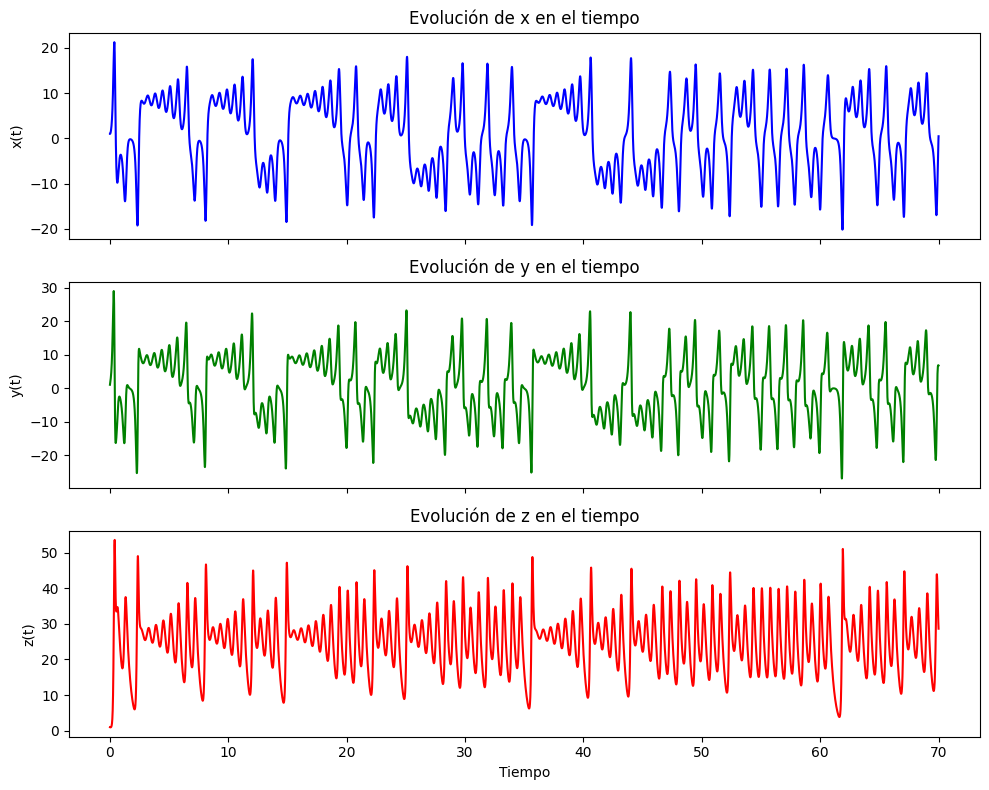

t= 70.00 s, X final: 0.4592, Y final: 6.7261, Z final: 28.6360

Simulando caso 2 con parámetros: {'rho': 28, 'sigma': 10, 'beta': 2.6666666666666665, 'init': (1.002025, 0.2, 0.4)}


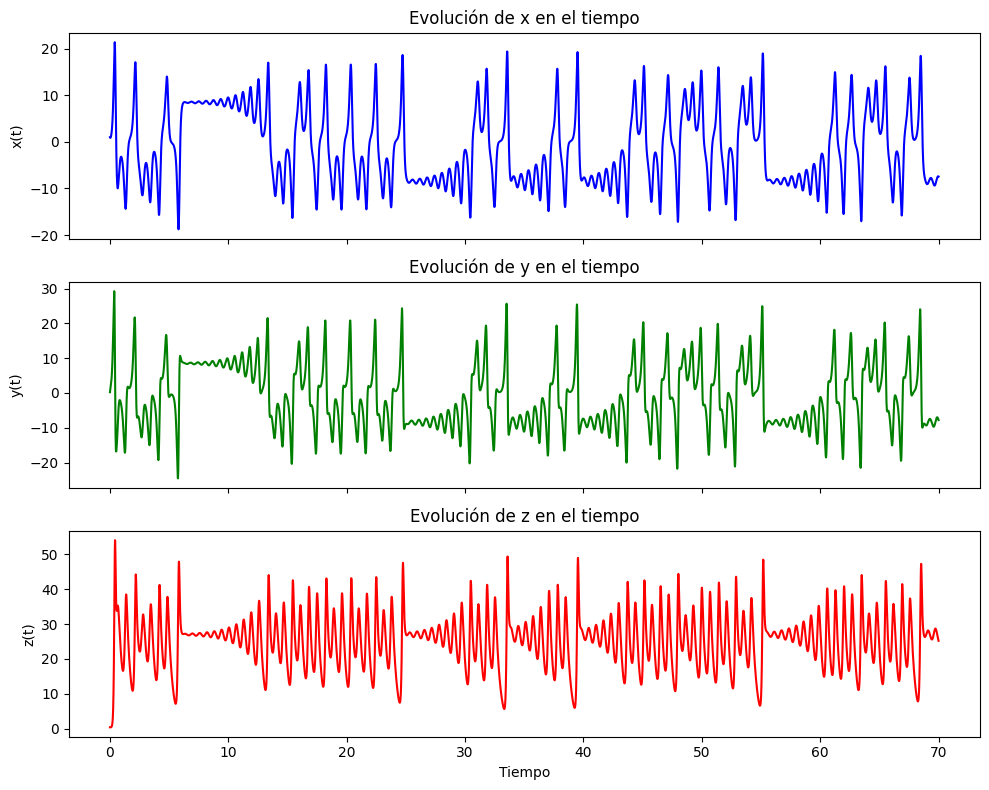

t= 70.00 s, X final: -7.4380, Y final: -7.8141, Z final: 25.1976

Simulando caso 3 con parámetros: {'rho': 18, 'sigma': 9, 'beta': 3.3333333333333335, 'init': (2, 0.009, 0.7)}


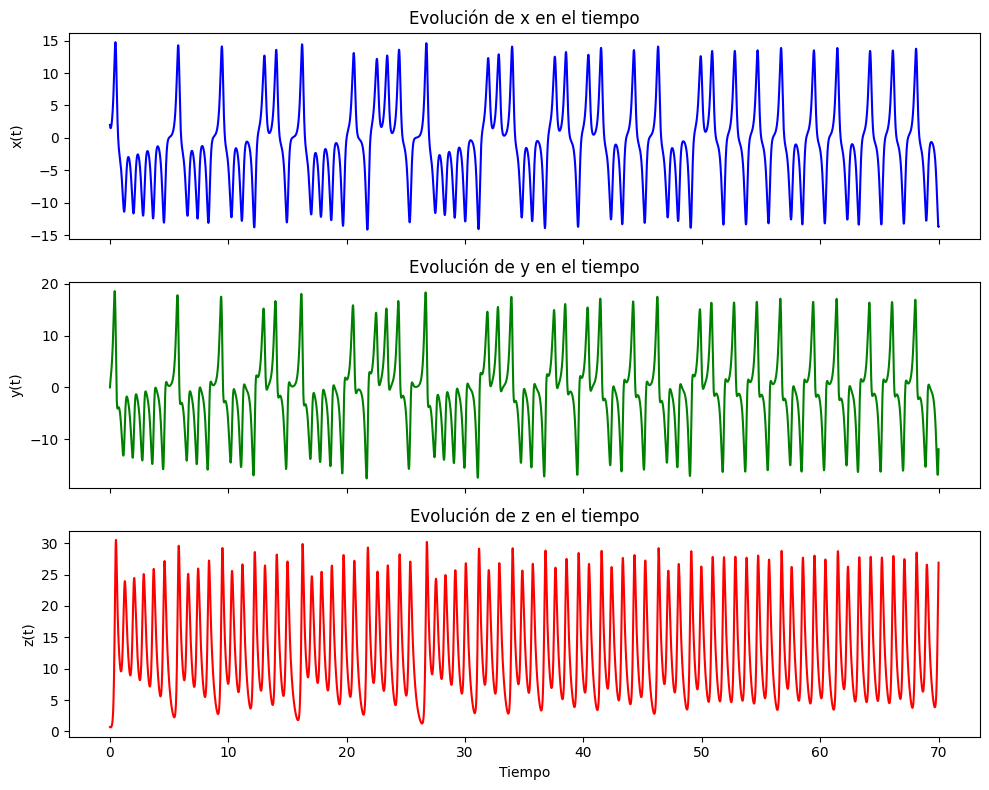

t= 70.00 s, X final: -13.6575, Y final: -11.9046, Z final: 26.8849


In [12]:
for i, case in enumerate(cases):
    print(f"\nSimulando caso {i+1} con parámetros: {case}")
    rho, sigma, beta = case["rho"], case["sigma"], case["beta"]
    x0, y0, z0 = case["init"]
    xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
    # Graficar evolución de las variables en el tiempo
    plot_lorenz_case(x0, y0, z0, sigma, rho, beta, dt, t_max)
    print(f"t= {t_max :.2f} s, X final: {xs[-1]:.4f}, Y final: {ys[-1]:.4f}, Z final: {zs[-1]:.4f}")